# Module 04 - Tokenization

Use this notebook as the working space for the Module 04 exercises.

1. Read the lesson page (`docs/modules/04-tokenizer.md`).
2. Open this notebook with `.venv/bin/python scripts/open_notebook.py 04`.
3. Answer the `Question:` / `Answer:` cells below.
4. When you're ready, ask a coding agent to grade your notebook.

Partial work is fine. Blank `Answer: ""` strings are skipped, not counted wrong. If you'd like a hint instead of a grade, write the request inline in the answer string and the agent will tutor first.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt

from g2c.artifacts import find_repo_root
from g2c.tokenizer import BPETokenizer, COURSE_SPECIAL_TOKENS

## Before the Notebook

Use the tests to implement the tokenizer pieces first. The notebook assumes `_get_pair_counts`, `_merge`, `train_step`, `encode`, and `decode` are available as you progress. The scaffolded `train()` loop, Rust-backed `train_fast()`/`encode_fast()`, and tokenizer save/load helpers are implemented for you.

In [2]:
"Run from the terminal: .venv/bin/python -m pytest tests/test_tokenizer.py -x"
"Question: Which tokenizer test is the next one failing, and what implementation does it point at?"
"Answer: "

'Answer: '

## Exercise 1 - Pair Counts and Merge

These two helpers are the BPE algorithm's core data-structure operations. Predict the outputs before running your implementation.

In [3]:
"Question: What adjacent-pair counts should [1, 2, 1, 2, 3] produce?"
"Answer: "

"Question: Why does a list of length n have only n - 1 adjacent pairs?"
"Answer: "

"Question: What should _merge([1, 1, 1], (1, 1), 99) return, and why?"
"Answer: "

'Answer: '

In [4]:
pair_count_example = [1, 2, 1, 2, 3]
merge_example = [1, 1, 1]

print(BPETokenizer._get_pair_counts(pair_count_example))
print(BPETokenizer._merge(merge_example, (1, 1), 99))

{(1, 2): 2, (2, 1): 1, (2, 3): 1}
[99, 1]


## Exercise 2 - Train BPE on a Tiny Corpus

Train on a very small repeated string first. Call one `train_step()` by hand, then let scaffolded `train()` repeat that step until the target vocabulary size is reached. This makes the learned merges easy to inspect by hand.

In [5]:
tiny_corpus = "the the the"

"Question: In the initial byte sequence for 'the the the', which adjacent pair should be most frequent?"
"Answer: "

"Question: If the target vocab size is 259, how many merges should be learned from a fresh tokenizer?"
"Answer: "

"Question: Why should the new token IDs start at 256?"
"Answer: "

'Answer: '

In [6]:
step_tok = BPETokenizer()
step_ids = list(tiny_corpus.encode("utf-8"))

print("one step:", step_tok.train_step(step_ids, new_id=len(step_tok.vocab)))
print("merges after one step:", step_tok.merges)
print("learned vocab after one step:", {i: step_tok.vocab[i] for i in range(256, len(step_tok.vocab))})


def print_bpe_progress(info: dict) -> None:
    print(
        f"step {info['steps']} | "
        f"vocab {info['vocab_size']}/{info['target_vocab_size']} | "
        f"last token {info['last_token_repr']} | "
        f"tokens {info['tokens']} | "
        f"last merge count {info['last_merge_count']} | "
        f"elapsed {info['elapsed_seconds']:.3f}s"
    )


tiny_tok = BPETokenizer()
tiny_tok.train(tiny_corpus, vocab_size=259, progress_callback=print_bpe_progress, progress_every=1)
print("merges:", tiny_tok.merges)
print("learned vocab:", {i: tiny_tok.vocab[i] for i in range(256, len(tiny_tok.vocab))})
assert len(tiny_tok.vocab) == 259

one step: ([256, 101, 32, 256, 101, 32, 256, 101], (116, 104), 3)
merges after one step: {(116, 104): 256}
learned vocab after one step: {256: b'th'}
step 1 | vocab 257/259 | last token 'th' | tokens 8 | last merge count 3 | elapsed 0.000s
step 2 | vocab 258/259 | last token 'the' | tokens 5 | last merge count 3 | elapsed 0.000s
step 3 | vocab 259/259 | last token 'the ' | tokens 3 | last merge count 2 | elapsed 0.000s
merges: {(116, 104): 256, (256, 101): 257, (257, 32): 258}
learned vocab: {256: b'th', 257: b'the', 258: b'the '}


## Exercise 3 - Encode, Decode, and Round Trip

A byte-level tokenizer should round-trip any UTF-8 text, including text with characters that were not in the training corpus.

In [7]:
"Question: Why can a byte-level tokenizer encode text it never saw during training?"
"Answer: "

"Question: During encode, why should the learned merge with the lowest new ID get priority?"
"Answer: "

"Question: What property of vocab entries makes decode lossless?"
"Answer: "

'Answer: '

In [8]:
roundtrip_texts = [
    "the theater there",
    "héllo wörld",
    "unseen text 12345 🌍",
]

roundtrip_tok = BPETokenizer()
roundtrip_tok.train("the quick brown fox jumps over the lazy dog " * 20, vocab_size=300)
for text in roundtrip_texts:
    ids = roundtrip_tok.encode(text)
    decoded = roundtrip_tok.decode(ids)
    print(text, "->", ids, "->", decoded)
    assert decoded == text

the theater there -> [258, 257, 97, 116, 101, 114, 32, 257, 114, 101] -> the theater there
héllo wörld -> [104, 195, 169, 108, 108, 111, 32, 119, 195, 182, 114, 108, 100] -> héllo wörld
unseen text 12345 🌍 -> [117, 110, 115, 101, 101, 110, 32, 116, 101, 120, 116, 32, 49, 50, 51, 52, 53, 32, 240, 159, 140, 141] -> unseen text 12345 🌍


## Exercise 4 - Special Tokens as Atomic Markers

Special tokens are reserved control strings. Later modules use them for document boundaries, chat roles, and tool-call events. They should encode as one token ID each, not as ordinary BPE pieces.

In [9]:
"Question: Why should <|assistant|> be one atomic ID instead of ordinary text pieces?"
"Answer: "

"Question: If a tokenizer reserves 8 special tokens, where should the first learned BPE merge ID start?"
"Answer: "

'Answer: '

In [10]:
special_tok = BPETokenizer.with_course_special_tokens()
chat_text = "<|user|>\nHello<|end|><|assistant|>\nHi!<|end|>"
chat_ids = special_tok.encode(chat_text)

print("course special tokens:")
for token in COURSE_SPECIAL_TOKENS:
    print(token, "->", special_tok.special_to_id[token])

print("\nencoded chat ids:", chat_ids)
assert special_tok.special_to_id["<|user|>"] in chat_ids
assert special_tok.special_to_id["<|assistant|>"] in chat_ids
assert chat_ids.count(special_tok.special_to_id["<|end|>"]) == 2
assert special_tok.decode(chat_ids) == chat_text
assert special_tok.base_vocab_size == 256 + len(COURSE_SPECIAL_TOKENS)

course special tokens:
<|endoftext|> -> 256
<|system|> -> 257
<|user|> -> 258
<|assistant|> -> 259
<|tool_call|> -> 260
<|tool_result|> -> 261
<|end|> -> 262
<|pad|> -> 263

encoded chat ids: [258, 10, 72, 101, 108, 108, 111, 262, 259, 10, 72, 105, 33, 262]


## Exercise 5 - Pre-Tokenization Demo

Production tokenizers (GPT-2, GPT-3, Llama) run a *pre-tokenizer* that splits the input into pieces (words, punctuation, whitespace runs) before BPE pair-counting kicks in. BPE then learns merges only **within** each piece, never across them. This prevents the trainer from inventing tokens like `the<|endoftext|>Once`. The cell below demonstrates the regex split GPT-2 uses.

In [11]:
"Question: Why might merging across whitespace create less useful tokens?"
"Answer: "

"Question: What would you compare before and after adding pre-tokenization?"
"Answer: "

'Answer: '

In [12]:
import re
from collections import Counter


def simple_pretokenize(text: str) -> list[str]:
    """Split into whitespace spans and non-whitespace spans."""
    return re.findall(r"\s+|\S+", text)


def pair_counts_within_pretokens(text: str) -> Counter[tuple[int, int]]:
    """Count adjacent byte pairs without crossing pre-token boundaries."""
    counts: Counter[tuple[int, int]] = Counter()
    for piece in simple_pretokenize(text):
        counts.update(BPETokenizer._get_pair_counts(list(piece.encode("utf-8"))))
    return counts


pretok_text = "the theater there and the theory"
raw_counts = Counter(BPETokenizer._get_pair_counts(list(pretok_text.encode("utf-8"))))
pretok_counts = pair_counts_within_pretokens(pretok_text)

print("pre-tokens:", simple_pretokenize(pretok_text))
print("raw top pairs:", raw_counts.most_common(8))
print("pre-tokenized top pairs:", pretok_counts.most_common(8))
print("\nNotice that pre-tokenized counts never include a pair crossing from the end of one word into the next span.")

pre-tokens: ['the', ' ', 'theater', ' ', 'there', ' ', 'and', ' ', 'the', ' ', 'theory']
raw top pairs: [((116, 104), 5), ((104, 101), 5), ((32, 116), 4), ((101, 32), 3), ((101, 114), 2), ((101, 97), 1), ((97, 116), 1), ((116, 101), 1)]
pre-tokenized top pairs: [((116, 104), 5), ((104, 101), 5), ((101, 114), 2), ((101, 97), 1), ((97, 116), 1), ((116, 101), 1), ((114, 101), 1), ((97, 110), 1)]

Notice that pre-tokenized counts never include a pair crossing from the end of one word into the next span.


## Train the TinyShakespeare tokenizer

The remaining exercises run on real text. TinyShakespeare (~1 MB) is small enough that we just retrain a tokenizer here every time this cell runs, so there's no "is the artifact stale?" guesswork. The artifact is saved to `artifacts/tokenizers/ShakespeareTokenizer/` for downstream modules to load.

In [13]:
from g2c.artifacts import (
    TokenizerArtifactConfig,
    train_or_load_tokenizer_artifact,
)
from g2c.notebook_extras.tokenizer import (
    inspect_tokenizer_artifact,
    make_artifact_display,
)

repo_root = find_repo_root()

In [14]:
shakespeare_config = TokenizerArtifactConfig(
    name="ShakespeareTokenizer",
    source="tinyshakespeare",
    vocab_size=4096,
    max_chars=1_000_000,
    use_fast=True,
    chunk_chars=8_192,
    notes="Reusable Shakespeare tokenizer for compression and inspection exercises.",
)

shakespeare_status = make_artifact_display(shakespeare_config.name)
shakespeare_artifact = train_or_load_tokenizer_artifact(
    shakespeare_config,
    repo_root=repo_root,
    force=True,
    progress_callback=shakespeare_status,
    status_callback=shakespeare_status,
)
print(f"trained vocab: {len(shakespeare_artifact.tokenizer.vocab):,}")
print(f"corpus chars: {len(shakespeare_artifact.text):,}")

ShakespeareTokenizer: trained vocab `4,096/4,096` | sample tokens `264,279` | chunks `123` | elapsed `2.2s`

saved ShakespeareTokenizer: 264,279 sample token IDs
trained vocab: 4,096
corpus chars: 1,000,000


## Exercise 6 - Vocab Size vs Compression

The previous cell trained a Shakespeare tokenizer to vocab 4096. Now sweep across smaller effective vocab sizes by truncating that same merge list and measuring how many tokens a fixed Shakespeare passage compresses to. The lesson is the *shape of the curve*, not the loop body — `train_and_measure` is provided.

In [15]:
"Question: What do you predict will happen to token count as vocab size increases?"
"Answer: "

"Question: Why might the improvement show diminishing returns?"
"Answer: "

"Question: What is the tradeoff of using a very large vocabulary in a real model?"
"Answer: "

'Answer: '

In [16]:
def train_and_measure(
    tokenizer: BPETokenizer,
    passage: str,
    vocab_sizes: list[int],
) -> list[dict]:
    """Re-encode `passage` with each truncated `vocab_size` of `tokenizer`.

    Pre-implemented: at this scale the experiment, not the loop body, is the
    lesson. Uses `encode_at_vocab`, so a single tokenizer trained to the
    largest vocab gives the same encoding a tokenizer trained to any smaller
    vocab on the same corpus would produce.
    """
    rows = []
    for vocab_size in vocab_sizes:
        ids = tokenizer.encode_at_vocab(passage, vocab_size)
        rows.append({
            "vocab_size": vocab_size,
            "tokens": len(ids),
            "chars_per_token": len(passage) / max(1, len(ids)),
        })
    return rows

  vocab=  264 |  2000 tokens | 1.00 chars/token
  vocab=  320 |  1363 tokens | 1.47 chars/token
  vocab=  512 |  1025 tokens | 1.95 chars/token
  vocab= 1024 |   778 tokens | 2.57 chars/token
  vocab= 2048 |   640 tokens | 3.12 chars/token
  vocab= 4096 |   538 tokens | 3.72 chars/token


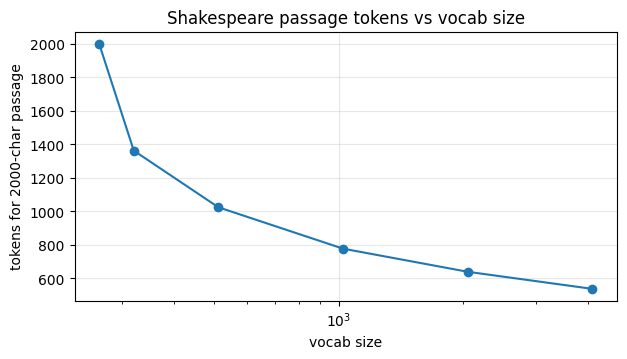

In [17]:
shakespeare_passage = shakespeare_artifact.text[:2000]
vocab_sizes = [
    shakespeare_artifact.tokenizer.base_vocab_size,
    320,
    512,
    1024,
    2048,
    4096,
]
compression_rows = train_and_measure(
    shakespeare_artifact.tokenizer,
    shakespeare_passage,
    vocab_sizes,
)
for row in compression_rows:
    print(
        f"  vocab={row['vocab_size']:>5} | "
        f"{row['tokens']:>5} tokens | "
        f"{row['chars_per_token']:.2f} chars/token"
    )

plt.figure(figsize=(7, 3.5))
plt.plot(
    [r["vocab_size"] for r in compression_rows],
    [r["tokens"] for r in compression_rows],
    "o-",
)
plt.xlabel("vocab size")
plt.ylabel(f"tokens for {len(shakespeare_passage)}-char passage")
plt.title("Shakespeare passage tokens vs vocab size")
plt.xscale("log")
plt.grid(True, alpha=0.3)
plt.show()

## Exercise 7 - Inspect Learned Tokens

Look at the actual byte sequences BPE learned. Token IDs just past the special-token reserved range should hold the most-frequent short patterns; the highest-numbered learned IDs should hold the longest learned phrases.

In [18]:
"Question: Why should token IDs just above 255 usually represent very common patterns?"
"Answer: "

"Question: What kind of learned token would count as corpus-specific rather than generally useful?"
"Answer: "

'Answer: '

In [19]:
def token_bytes_display(token_bytes: bytes) -> str:
    """Display bytes as text when possible, with escapes for non-printing bytes."""
    return token_bytes.decode("utf-8", errors="backslashreplace")


def learned_vocab_window(tok: BPETokenizer, n: int = 20) -> tuple[list[tuple[int, str]], list[tuple[int, str]]]:
    """Return first and last n learned vocab entries as printable pairs."""
    # TODO: collect learned IDs, i.e. IDs >= tok.base_vocab_size
    # TODO: return first n and last n entries as (id, display_text) tuples
    raise NotImplementedError("inspect learned vocab entries")

first 20 learned tokens (IDs 264..283):
  264: 'e '
  265: 'th'
  266: 't '
  267: 's '
  268: 'd '
  269: ', '
  270: 'ou'
  271: 'er'
  272: 'in'
  273: 'y '
  274: 'an'
  275: 'or'
  276: ':\n'
  277: 'o '
  278: 'en'
  279: 'ar'
  280: '\n\n'
  281: ' th'
  282: 'on'
  283: 'll'

last 20 learned tokens (IDs 4076..4095):
  4076: 'HOP'
  4077: 'Isabel'
  4078: 'LEY'
  4079: 'Men'
  4080: 'Pet'
  4081: 'Rut'
  4082: 'Sic'
  4083: "That's "
  4084: 'cam'
  4085: 'corn'
  4086: "d's "
  4087: 'drop'
  4088: 'e. '
  4089: 'equ'
  4090: 'fly '
  4091: 'ge\n'
  4092: 'grown'
  4093: 'hur'
  4094: 'his\n'
  4095: 'ier'
ShakespeareTokenizer
trainer: rust-tokenizers
vocab size: 4096
sample token count: 264279
encoded sample chars: 1000000
chars/token: 3.784

Sample text:
'he bloody king.\nAnd here he comes.\nAll hail, my sovereign liege!\n\nKING RICHARD III:\nKind Tyrrel, am I happy in thy news?\n\nTYRREL:\nIf to have done the thing you gave in charge\nBeget your happiness, be happy then,\nFo

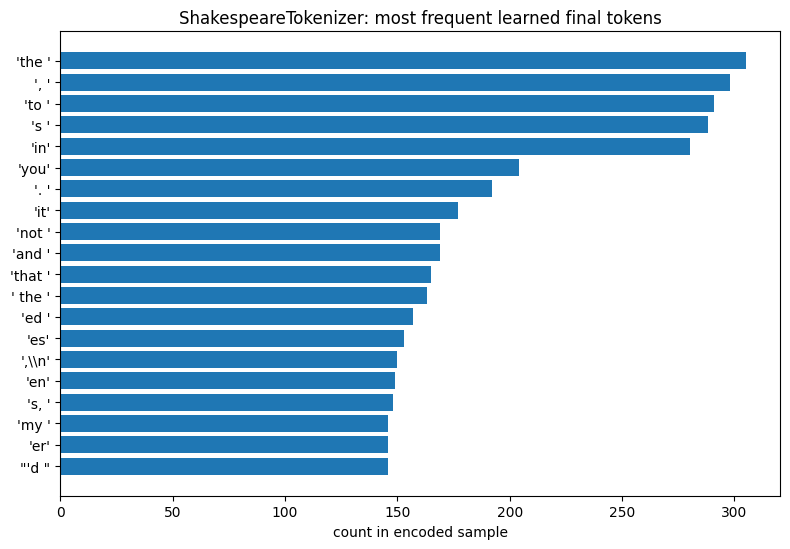

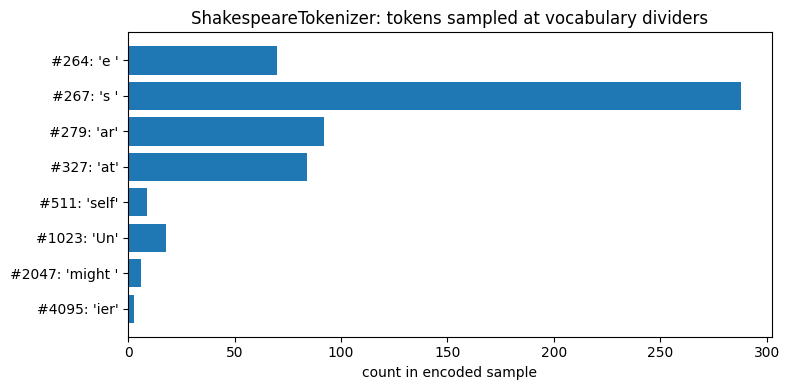

In [20]:
shakespeare_tok = shakespeare_artifact.tokenizer
base = shakespeare_tok.base_vocab_size

print(f"first 20 learned tokens (IDs {base}..{base + 19}):")
for token_id in range(base, base + 20):
    print(f"  {token_id}: {token_bytes_display(shakespeare_tok.vocab[token_id])!r}")

print(f"\nlast 20 learned tokens (IDs {len(shakespeare_tok.vocab) - 20}..{len(shakespeare_tok.vocab) - 1}):")
for token_id in range(len(shakespeare_tok.vocab) - 20, len(shakespeare_tok.vocab)):
    print(f"  {token_id}: {token_bytes_display(shakespeare_tok.vocab[token_id])!r}")

inspect_tokenizer_artifact(shakespeare_artifact)

In [21]:
"Question: Name two early learned tokens and explain why they are plausible frequent patterns."
"Answer: "

"Question: Name one late learned token and explain what makes it more specific."
"Answer: "

'Answer: '

## Exercise 8 - TinyStories Tokenizer (optional)

Train a tokenizer on 25M characters of TinyStories with vocab 8192. The artifact saves to `artifacts/tokenizers/StoryTokenizer/` for Module 10's StoryLM to load.

**Heads up: this cell takes ~10 minutes on an M-series Mac.** It always retrains and resaves the artifact when run — skip the cell if you don't need the tokenizer right now.

StoryTokenizer: trained vocab `8,193/8,192` | sample tokens `159,783` | chunks `3,050` | elapsed `12.9s`

saved StoryTokenizer: 159,783 sample token IDs
StoryTokenizer
trainer: rust-tokenizers
vocab size: 8193
sample token count: 159783
encoded sample chars: 1000000
chars/token: 6.258

Sample text:
'nd asked, "What\'s wrong, Lily?" Lily said, "I want to climb the tall tree, but I\'m scared." Her mom said, "Don\'t be scared. I\'ll help you climb it."\nSo, Lily and her mom climbed the tall tree together. When they reached the top, Lily said, "I can see everything from up here!" Her mom smiled and said, "I\'m glad you\'re not scared anymore." They both enjoyed th'

Token strings for sample:
['nd ', 'asked, "', "What's wrong", ', Lily', '?" Lily ', 'said, "I want to ', 'climb the ', 'tall ', 'tre', 'e, but ', "I'm ", 'scared', '." ', 'Her mom ', 'said, "', "Don't be ", 'scared', ". I'll ", 'help you ', 'climb ', 'it', '."\\n', 'So, ', 'Lily and her mom ', 'climbed the ', 'tall ', 'tree ', 'together', '. When ', 'they ', 'reached the top', ', Lily ', 'said, "I ', 'can ', 'see ', 'everything ', 

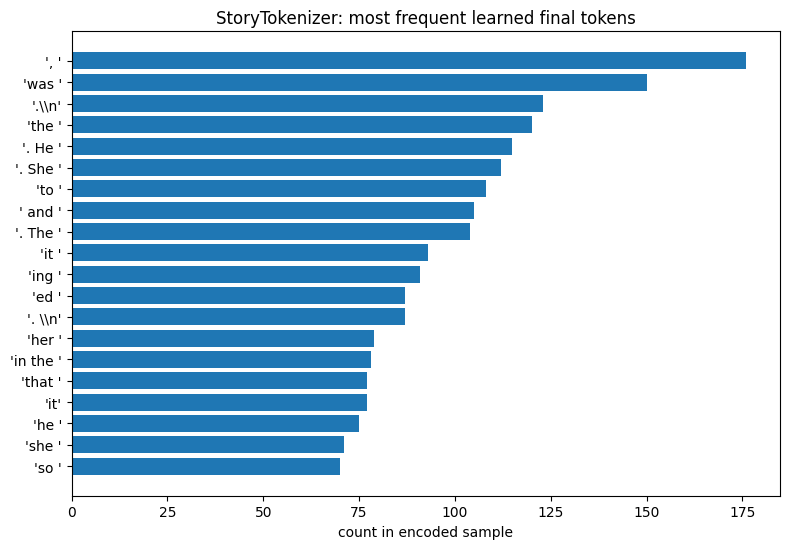

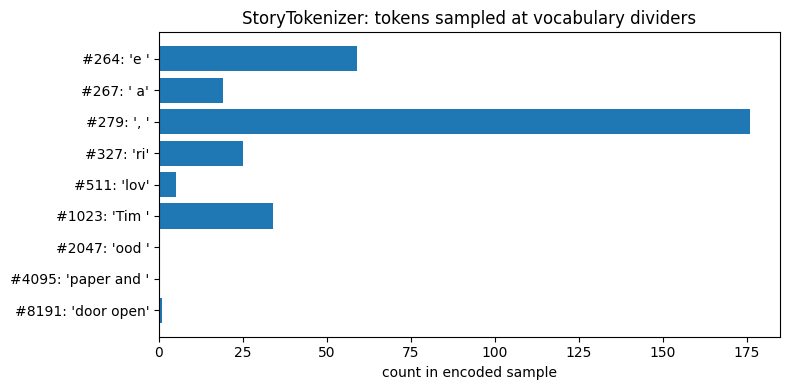

In [22]:
tinystories_config = TokenizerArtifactConfig(
    name="StoryTokenizer",
    source="tinystories",
    vocab_size=8192,
    max_chars=25_000_000,
    use_fast=True,
    chunk_chars=8_192,
    notes="TinyStories tokenizer for StoryLM. ~10 minute training run.",
)

tinystories_status = make_artifact_display(tinystories_config.name)
tinystories_artifact = train_or_load_tokenizer_artifact(
    tinystories_config,
    repo_root=repo_root,
    force=True,
    progress_callback=tinystories_status,
    status_callback=tinystories_status,
)
if tinystories_artifact is not None:
    inspect_tokenizer_artifact(tinystories_artifact)

## Exercise 9 - G2C Corpus Tokenizer (optional)

Train a broader tokenizer on 100M characters of the mixed G2C corpus with vocab 16384. The artifact powers later TinyLLM-small experiments.

**Heads up: this cell takes about an hour.** It always retrains and resaves when run — skip unless you're ready to commit the time.

G2CTokenizer: trained vocab `16,381/16,384` | sample tokens `198,519` | chunks `12,167` | elapsed `78.6s`

saved G2CTokenizer: 198,519 sample token IDs
G2CTokenizer
trainer: rust-tokenizers
vocab size: 16381
sample token count: 198519
encoded sample chars: 1000000
chars/token: 5.037

Sample text:
'enter of attention. Siamese cats thrive on human interaction and are known to form strong bonds with their owners. They often follow their humans around the house, offering constant companionship and loyalty.\nSiamese cats are also known for their vocal nature. They have a wide range of vocalizations and are not afraid to use them to communicate their needs o'

Token strings for sample:
['ent', 'er of ', 'attention', '. S', 'i', 'am', 'ese ', 'cats ', 'thrive ', 'on ', 'human ', 'inter', 'ac', 'tion and ', 'are ', 'known ', 'to ', 'form ', 'strong ', 'bond', 's with ', 'their ', 'own', 'ers', '. They ', 'often ', 'follow ', 'their ', 'humans ', 'around the ', 'house, ', 'offering ', 'constant ', 'companion', 'ship and ', 'loyal', 'ty', '.\\nS', 'i', 'am', 'ese ', 'cat', 's are also ', 'known ', 'f

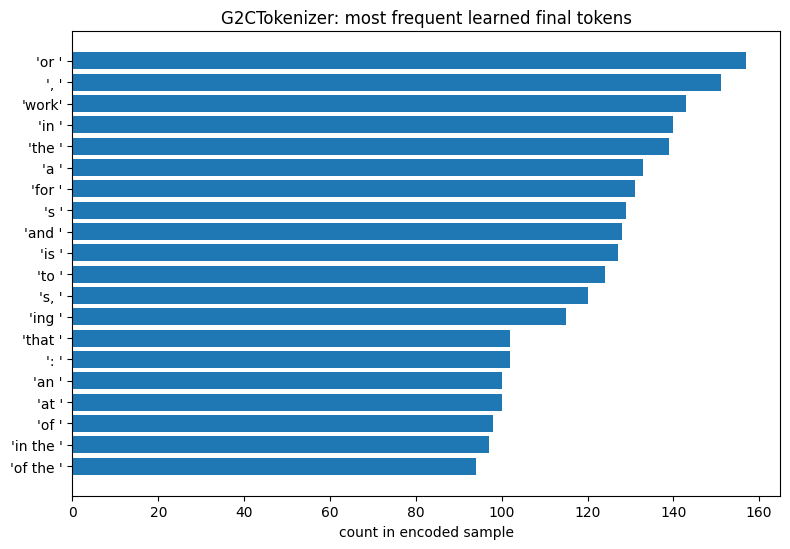

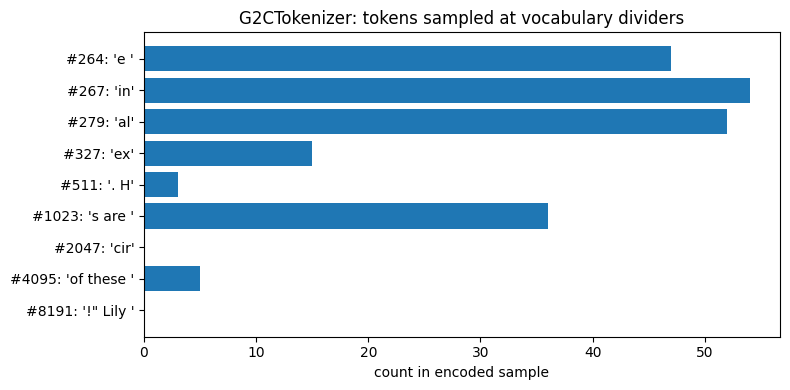

In [23]:
g2c_config = TokenizerArtifactConfig(
    name="G2CTokenizer",
    source="g2c",
    vocab_size=16384,
    max_chars=100_000_000,
    use_fast=True,
    chunk_chars=8_192,
    notes="Broad course-corpus tokenizer for TinyLLM-small experiments. ~1 hour training run.",
)

g2c_status = make_artifact_display(g2c_config.name)
g2c_artifact = train_or_load_tokenizer_artifact(
    g2c_config,
    repo_root=repo_root,
    force=True,
    progress_callback=g2c_status,
    status_callback=g2c_status,
)
if g2c_artifact is not None:
    inspect_tokenizer_artifact(g2c_artifact)

## Submission Notes

When complete, ask a coding agent to grade your Module 04 notebook. Partial work is fine: the agent should grade answered questions and implemented sections, then skip blank prompts.